# Online retail dataset

## Task 1 – Data Import & Setup

In [ ]:
import pandas as pd

In [41]:
df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format="%d-%m-%Y %H:%M")

print(df.shape)
print(df.head(3))


(541909, 8)
  InvoiceNo StockCode                         Description  Quantity  \
0    536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                 WHITE METAL LANTERN         6   
2    536365    84406B      CREAM CUPID HEARTS COAT HANGER         8   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55       17850  United Kingdom  
1 2010-12-01 08:26:00       3.39       17850  United Kingdom  
2 2010-12-01 08:26:00       2.75       17850  United Kingdom  


## Task 2 – Data Cleaning

In [40]:
df = df.dropna(subset=['CustomerID'])
df = df.drop_duplicates()
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]


## Task 3 – Feature Engineering

In [39]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

df['OrderSize'] = pd.cut(df['Quantity'], bins=[0,10,50,100,1000],
                         labels=['Small','Medium','Large','Bulk'])


## Task 4 – Data Exploration

In [38]:
print(df.describe())
print(df['Country'].value_counts().head(5))


            Quantity                    InvoiceDate      UnitPrice  \
count  524878.000000                         524878  524878.000000   
mean       10.616600  2011-07-04 15:30:16.317049088       3.922573   
min         1.000000            2010-12-01 08:26:00       0.001000   
25%         1.000000            2011-03-28 12:13:00       1.250000   
50%         4.000000            2011-07-20 11:22:00       2.080000   
75%        11.000000            2011-10-19 11:41:00       4.130000   
max     80995.000000            2011-12-09 12:50:00   13541.330000   
std       156.280031                            NaN      36.093028   

          CustomerID     TotalPrice           Year          Month  \
count  524878.000000  524878.000000  524878.000000  524878.000000   
mean    11437.732164      20.275399    2010.921904       7.552237   
min         0.000000       0.001000    2010.000000       1.000000   
25%         0.000000       3.900000    2011.000000       5.000000   
50%     14350.000000    

## Task 5 – Data Wrangling

In [37]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(5)
print(top_customers)

top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(5)
print(top_countries)


CustomerID
0        1754901.91
14646     280206.02
18102     259657.30
17450     194390.79
16446     168472.50
Name: TotalPrice, dtype: float64
Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Name: TotalPrice, dtype: float64


## Task 6 – Statistical Analysis

In [36]:
print("Mean Quantity:", df['Quantity'].mean())
print("Median Quantity:", df['Quantity'].median())
print("Mode Quantity:", df['Quantity'].mode()[0])
print("Std Dev TotalPrice:", df['TotalPrice'].std())
print("Variance TotalPrice:", df['TotalPrice'].var())
print("Percentiles:", df['TotalPrice'].quantile([0.25,0.5,0.75]))


Mean Quantity: 10.616600429052085
Median Quantity: 4.0
Mode Quantity: 1
Std Dev TotalPrice: 271.6935662992457
Variance TotalPrice: 73817.39396840261
Percentiles: 0.25     3.90
0.50     9.92
0.75    17.70
Name: TotalPrice, dtype: float64


## Task 7 – Data Visualization

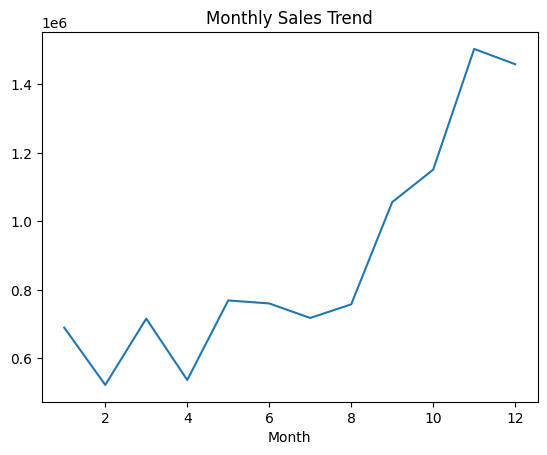

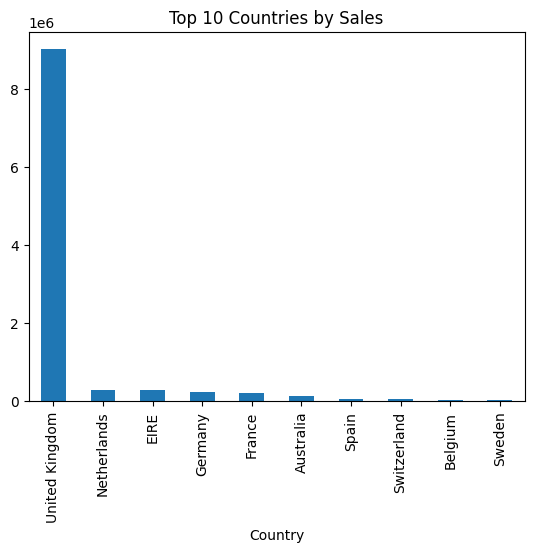

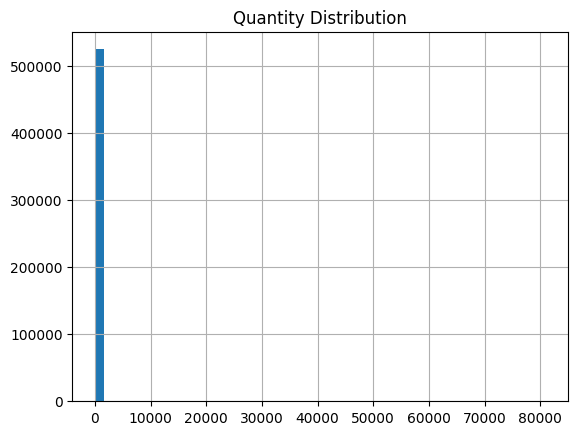

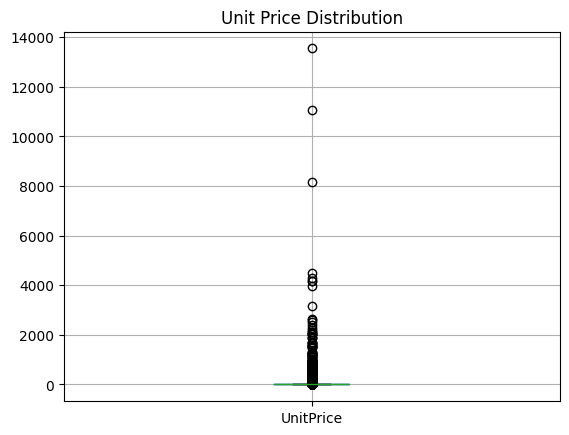

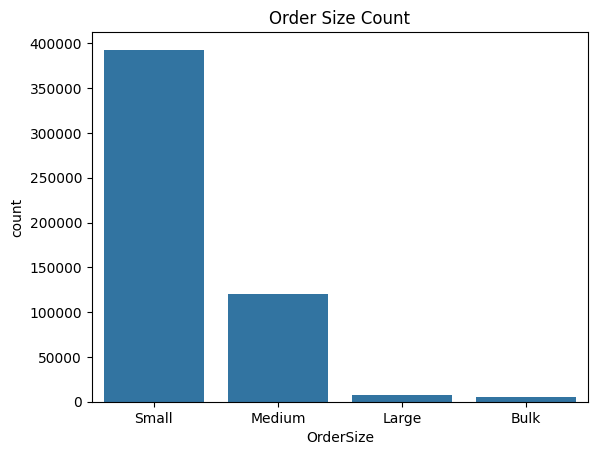

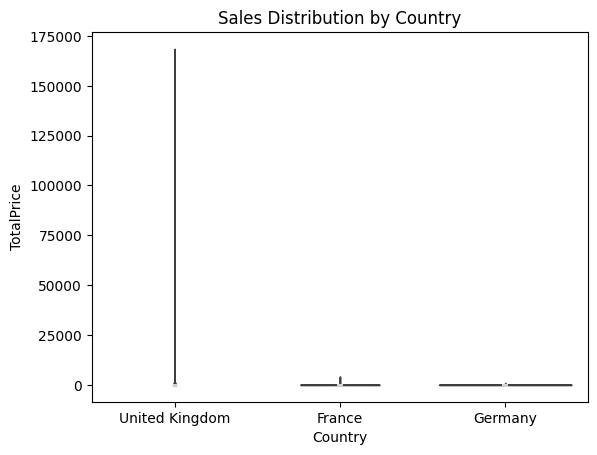

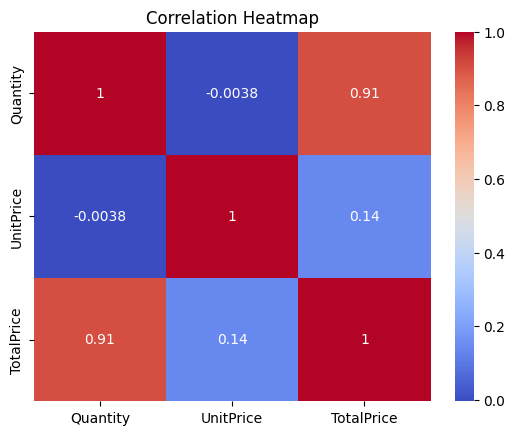

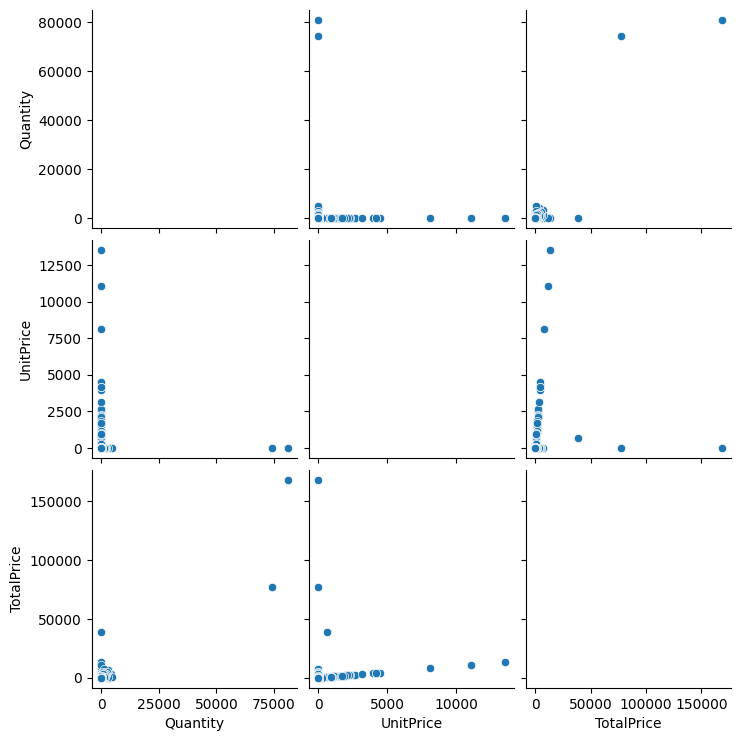

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Line chart - Monthly sales trend
df.groupby('Month')['TotalPrice'].sum().plot(kind='line')
plt.title("Monthly Sales Trend")
plt.show()

# Bar chart - Country sales
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Countries by Sales")
plt.show()

# Histogram - Quantity
df['Quantity'].hist(bins=50)
plt.title("Quantity Distribution")
plt.show()

# Box plot - UnitPrice
df.boxplot(column='UnitPrice')
plt.title("Unit Price Distribution")
plt.show()

# Seaborn plots
sns.countplot(x='OrderSize', data=df)
plt.title("Order Size Count")
plt.show()

sns.violinplot(x='Country', y='TotalPrice', data=df[df['Country'].isin(['United Kingdom','Germany','France'])])
plt.title("Sales Distribution by Country")
plt.show()

sns.heatmap(df[['Quantity','UnitPrice','TotalPrice']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(df[['Quantity','UnitPrice','TotalPrice']])
plt.show()


## Task 8 – Business Insights
Top Country: United Kingdom

Best Sales Month: December (holiday season)

Peak Sales Time: Morning hours (8–11 AM)

Customer Behavior: Majority small orders, but bulk buyers contribute heavily

High-Value Customers: Top 5 customers account for significant revenue

Top Products: Household and seasonal items